In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("googleplaystore.csv")
print("Original shape:", df.shape)
print(df.head())

Original shape: (10841, 17)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0

In [2]:
# Drop ONLY rows missing in important columns
df.dropna(subset=["App", "Category", "Rating", "Type", "Installs"], inplace=True)

# Remove duplicates
df.drop_duplicates(subset="App", keep="first", inplace=True)

# Fix Rating
df = df[df["Rating"] <= 5.0]

# Fix Installs
df["Installs"] = df["Installs"].astype(str).str.replace("[+,]", "", regex=True)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Fix Price
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Fix Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Save
df.to_csv("cleaned_playstore.csv", index=False)
print("Cleaned shape:", df.shape)
print("Cleaning done!")

Cleaned shape: (8196, 17)
Cleaning done!


In [3]:
print("Rows:", len(df))
print("Categories found:", df["Category"].nunique())
print(df["Category"].value_counts().head(5))

Rows: 8196
Categories found: 33
Category
FAMILY       1608
GAME          912
TOOLS         718
FINANCE       302
LIFESTYLE     301
Name: count, dtype: int64


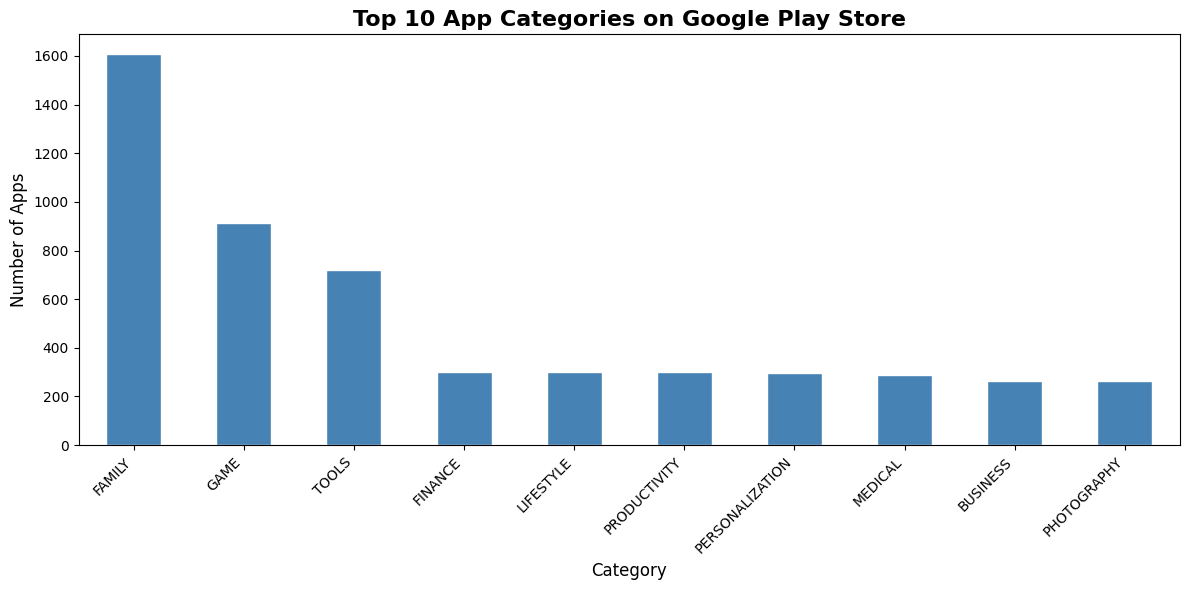

In [4]:
category_counts = df["Category"].value_counts().head(10) 
  
# Create bar chart 
plt.figure(figsize=(12, 6)) 
category_counts.plot(kind="bar", color="steelblue", edgecolor="white") 
plt.title("Top 10 App Categories on Google Play Store", fontsize=16, 
fontweight="bold") 
plt.xlabel("Category", fontsize=12) 
plt.ylabel("Number of Apps", fontsize=12) 
plt.xticks(rotation=45, ha="right") 
plt.tight_layout() 
plt.savefig("chart1_top_categories.png") 
plt.show() 

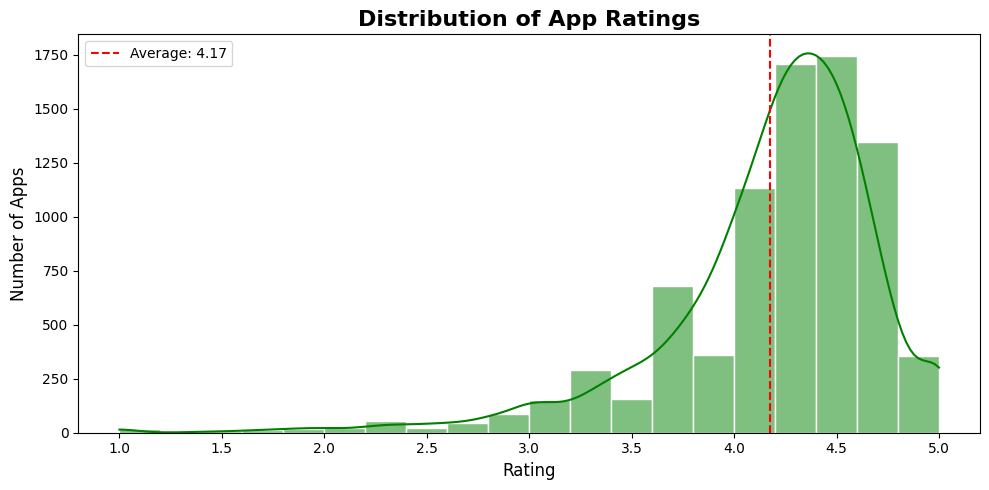

In [5]:
# Histogram of ratings 
plt.figure(figsize=(10, 5)) 
sns.histplot(df["Rating"], bins=20, kde=True, color="green", edgecolor="white") 
plt.title("Distribution of App Ratings", fontsize=16, fontweight="bold") 
plt.xlabel("Rating", fontsize=12) 
plt.ylabel("Number of Apps", fontsize=12) 
plt.axvline(df["Rating"].mean(), color="red", linestyle="--", 
            label=f"Average: {df['Rating'].mean():.2f}") 
plt.legend() 
plt.tight_layout() 
plt.savefig("chart2_rating_distribution.png") 
plt.show()

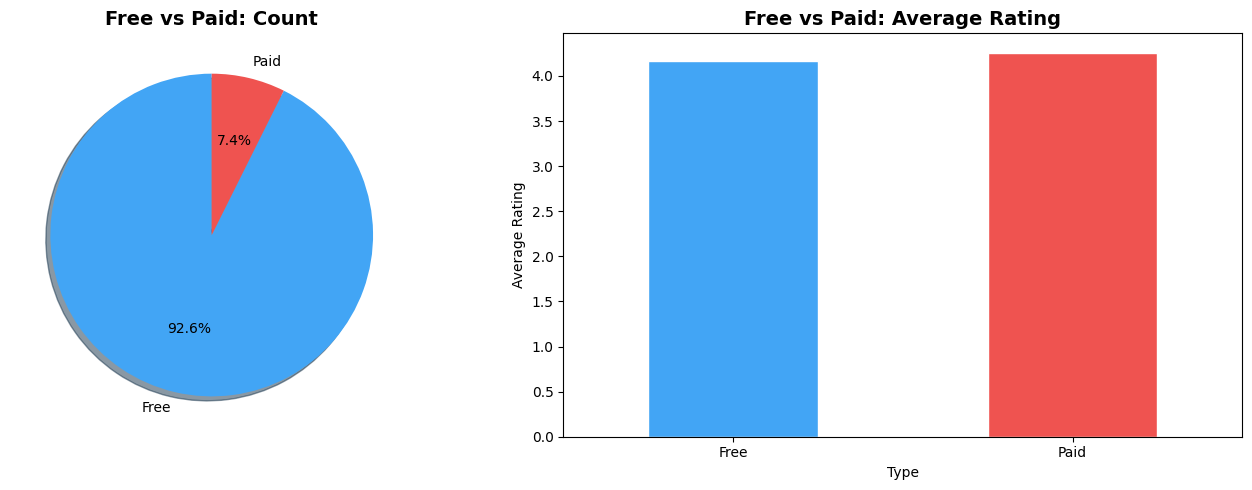

In [6]:
# Compare free and paid apps 
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
  
# Chart A: Count 
df["Type"].value_counts().plot(kind="pie", ax=axes[0], 
    autopct="%1.1f%%", colors=["#42A5F5", "#EF5350"], 
    startangle=90, shadow=True) 
axes[0].set_title("Free vs Paid: Count", fontsize=14, fontweight="bold")
# Chart B: Average Rating 
df.groupby("Type")["Rating"].mean().plot(kind="bar", ax=axes[1], 
    color=["#42A5F5", "#EF5350"], edgecolor="white") 
axes[1].set_title("Free vs Paid: Average Rating", fontsize=14, 
fontweight="bold") 
axes[1].set_ylabel("Average Rating") 
axes[1].set_xticklabels(["Free", "Paid"], rotation=0) 
  
plt.tight_layout() 
plt.savefig("chart3_free_vs_paid.png") 
plt.show()

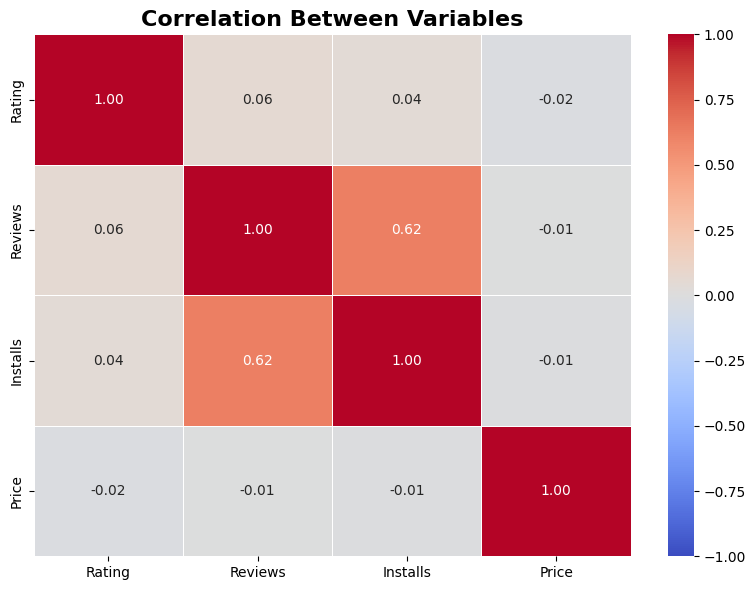

In [7]:
# Check relationships between numeric columns 
plt.figure(figsize=(8, 6)) 
numeric_cols = df[["Rating", "Reviews", "Installs", "Price"]].copy() 
numeric_cols.dropna(inplace=True) 
  
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", 
            fmt=".2f", linewidths=0.5, vmin=-1, vmax=1) 
plt.title("Correlation Between Variables", fontsize=16, fontweight="bold") 
plt.tight_layout() 
plt.savefig("chart4_heatmap.png") 
plt.show() 

In [8]:
# T-test: Are Free app ratings different from Paid? 
free_ratings = df[df["Type"] == "Free"]["Rating"].dropna() 
paid_ratings = df[df["Type"] == "Paid"]["Rating"].dropna() 
  
t_stat, p_value = stats.ttest_ind(free_ratings, paid_ratings) 
  
print(f"Free app avg rating:  {free_ratings.mean():.2f}") 
print(f"Paid app avg rating:  {paid_ratings.mean():.2f}") 
print(f"T-statistic: {t_stat:.4f}") 
print(f"P-value:     {p_value:.4f}") 
  
if p_value < 0.05: 
    print("RESULT: Significant difference! (p < 0.05)") 
else: 
    print("RESULT: No significant difference (p >= 0.05)")

Free app avg rating:  4.17
Paid app avg rating:  4.26
T-statistic: -4.1134
P-value:     0.0000
RESULT: Significant difference! (p < 0.05)
